# 🛒 Basic EDA on Supermarket Sales Data

**Objective:** Perform exploratory data analysis to understand sales patterns across branches, product lines, and customer types using groupby and visualizations.

**Tools:** pandas, matplotlib, seaborn

---

## 1. Import Libraries & Load Data

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# Load the dataset
df = pd.read_csv('supermarket_sales - Sheet1.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumn names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

df.head()

Dataset shape: 1000 rows × 17 columns

Column names:
  1. Invoice ID
  2. Branch
  3. City
  4. Customer type
  5. Gender
  6. Product line
  7. Unit price
  8. Quantity
  9. Tax 5%
  10. Total
  11. Date
  12. Time
  13. Payment
  14. cogs
  15. gross margin percentage
  16. gross income
  17. Rating


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Data Quality Check

In [3]:
# Check data types
print('='*50)
print('DATA TYPES')
print('='*50)
print(df.dtypes)

print('\n' + '='*50)
print('MISSING VALUES')
print('='*50)
missing = df.isnull().sum()
print(missing)
print(f'\n✅ Total missing values: {missing.sum()}')

print('\n' + '='*50)
print('DUPLICATE ROWS')
print('='*50)
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

DATA TYPES
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

MISSING VALUES
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment         

In [4]:
# Descriptive statistics for numerical columns
print('DESCRIPTIVE STATISTICS')
print('='*80)
df.describe().round(2)

DESCRIPTIVE STATISTICS


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


In [5]:
# Unique values in categorical columns
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

print('UNIQUE VALUES IN CATEGORICAL COLUMNS')
print('='*50)
for col in categorical_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(f'  → {df[col].unique().tolist()}')

UNIQUE VALUES IN CATEGORICAL COLUMNS

Branch: 3 unique values
  → ['A', 'C', 'B']

City: 3 unique values
  → ['Yangon', 'Naypyitaw', 'Mandalay']

Customer type: 2 unique values
  → ['Member', 'Normal']

Gender: 2 unique values
  → ['Female', 'Male']

Product line: 6 unique values
  → ['Health and beauty', 'Electronic accessories', 'Home and lifestyle', 'Sports and travel', 'Food and beverages', 'Fashion accessories']

Payment: 3 unique values
  → ['Ewallet', 'Cash', 'Credit card']


## 3. Data Preprocessing

Convert `Date` and `Time` columns to appropriate datetime formats and extract useful features.

In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Convert Time column to datetime.time
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

# Extract useful time features
df['Hour'] = df['Time'].apply(lambda x: x.hour)
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()

print('✅ Date and Time columns converted successfully')
print(f'\nDate range: {df["Date"].min().strftime("%Y-%m-%d")} to {df["Date"].max().strftime("%Y-%m-%d")}')
print(f'\nData types after conversion:')
print(df[['Date', 'Time', 'Hour', 'Day_of_Week', 'Month']].dtypes)

df[['Invoice ID', 'Date', 'Time', 'Hour', 'Day_of_Week', 'Month']].head()

✅ Date and Time columns converted successfully

Date range: 2019-01-01 to 2019-03-30

Data types after conversion:
Date           datetime64[ns]
Time                   object
Hour                    int64
Day_of_Week            object
Month                  object
dtype: object


,Invoice ID,Date,Time,Hour,Day_of_Week,Month
0,750-67-8428,2019-01-05,13:08:00,13,Saturday,January
1,226-31-3081,2019-03-08,10:29:00,10,Friday,March
2,631-41-3108,2019-03-03,13:23:00,13,Sunday,March
3,123-19-1176,2019-01-27,20:33:00,20,Sunday,January
4,373-73-7910,2019-02-08,10:37:00,10,Friday,February


## 4. Groupby Analysis

Aggregate total sales and order count by **Branch**, **Product Line**, **Customer Type**, and **Gender**.

In [7]:
# ─── 4.1 Total Sales & Order Count by BRANCH ───
branch_analysis = df.groupby('Branch').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).round(2)

# Add city mapping for context
branch_city = df.groupby('Branch')['City'].first()
branch_analysis['City'] = branch_city

print('📊 SALES ANALYSIS BY BRANCH')
print('='*70)
branch_analysis

📊 SALES ANALYSIS BY BRANCH


,Total_Sales,Order_Count,Avg_Order_Value,Avg_Rating,City
Branch,,,,,
A,106200.37,340,312.35,7.03,Yangon
B,106197.67,332,319.87,6.82,Mandalay
C,110568.71,328,337.10,7.07,Naypyitaw


In [8]:
# ─── 4.2 Total Sales & Order Count by PRODUCT LINE ───
product_analysis = df.groupby('Product line').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Rating=('Rating', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

print('📊 SALES ANALYSIS BY PRODUCT LINE')
print('='*80)
product_analysis

📊 SALES ANALYSIS BY PRODUCT LINE


,Total_Sales,Order_Count,Avg_Order_Value,Avg_Quantity,Avg_Rating
Product line,,,,,
Food and beverages,56144.84,174,322.67,5.47,7.11
Sports and travel,55122.83,166,332.07,5.54,6.92
Electronic accessories,54337.53,170,319.63,5.71,6.92
Fashion accessories,54305.90,178,305.09,5.07,7.03
Home and lifestyle,53861.91,160,336.64,5.69,6.84
Health and beauty,49193.74,152,323.64,5.62,7.00


In [9]:
# ─── 4.3 Total Sales & Order Count by CUSTOMER TYPE ───
customer_analysis = df.groupby('Customer type').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).round(2)

print('📊 SALES ANALYSIS BY CUSTOMER TYPE')
print('='*70)
customer_analysis

📊 SALES ANALYSIS BY CUSTOMER TYPE


,Total_Sales,Order_Count,Avg_Order_Value,Avg_Rating
Customer type,,,,
Member,164223.44,501,327.79,6.94
Normal,158743.30,499,318.12,7.01


In [10]:
# ─── 4.4 Total Sales & Order Count by GENDER ───
gender_analysis = df.groupby('Gender').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean'),
    Avg_Rating=('Rating', 'mean')
).round(2)

print('📊 SALES ANALYSIS BY GENDER')
print('='*70)
gender_analysis

📊 SALES ANALYSIS BY GENDER


,Total_Sales,Order_Count,Avg_Order_Value,Avg_Rating
Gender,,,,
Female,167882.92,501,335.10,6.96
Male,155083.82,499,310.79,6.98


## 5. Time Analysis

Find the **busiest hours** and analyze hourly sales patterns.

In [11]:
# ─── 5.1 Hourly order count and total sales ───
hourly_analysis = df.groupby('Hour').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean')
).round(2)

print('📊 HOURLY SALES ANALYSIS')
print('='*60)
print(hourly_analysis.to_string())

# Find the busiest and slowest hours
busiest_hour = hourly_analysis['Order_Count'].idxmax()
slowest_hour = hourly_analysis['Order_Count'].idxmin()

print(f'\n🔥 Busiest hour: {busiest_hour}:00 with {hourly_analysis.loc[busiest_hour, "Order_Count"]} orders')
print(f'😴 Slowest hour: {slowest_hour}:00 with {hourly_analysis.loc[slowest_hour, "Order_Count"]} orders')

📊 HOURLY SALES ANALYSIS
      Total_Sales  Order_Count  Avg_Order_Value
Hour                                           
10       31421.48          101           311.10
11       30377.33           90           337.53
12       26065.88           89           292.88
13       34723.23          103           337.12
14       30828.40           83           371.43
15       31179.51          102           305.68
16       25226.32           77           327.61
17       24445.22           74           330.34
18       26030.34           93           279.90
19       39699.51          113           351.32
20       22969.53           75           306.26

🔥 Busiest hour: 19:00 with 113 orders
😴 Slowest hour: 17:00 with 74 orders


## 6. Top & Bottom Performing Product Lines

In [12]:
# ─── 6.1 Top performing product lines by total revenue ───
product_revenue = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).round(2)

print('🏆 TOP PERFORMING PRODUCT LINES (by Total Revenue)')
print('='*55)
for i, (product, revenue) in enumerate(product_revenue.items(), 1):
    marker = '🥇' if i == 1 else ('🥈' if i == 2 else ('🥉' if i == 3 else '  '))
    print(f'{marker} {i}. {product:<30} ${revenue:>12,.2f}')

print(f'\n✅ Top performer: {product_revenue.index[0]} (${product_revenue.iloc[0]:,.2f})')
print(f'⚠️ Bottom performer: {product_revenue.index[-1]} (${product_revenue.iloc[-1]:,.2f})')
print(f'\n📊 Difference: ${product_revenue.iloc[0] - product_revenue.iloc[-1]:,.2f}')

🏆 TOP PERFORMING PRODUCT LINES (by Total Revenue)
🥇 1. Food and beverages             $   56,144.84
🥈 2. Sports and travel              $   55,122.83
🥉 3. Electronic accessories         $   54,337.53
   4. Fashion accessories            $   54,305.90
   5. Home and lifestyle             $   53,861.91
   6. Health and beauty              $   49,193.74

✅ Top performer: Food and beverages ($56,144.84)
⚠️ Bottom performer: Health and beauty ($49,193.74)

📊 Difference: $6,951.10


## 7. Visualizations

Create multiple charts to support findings.

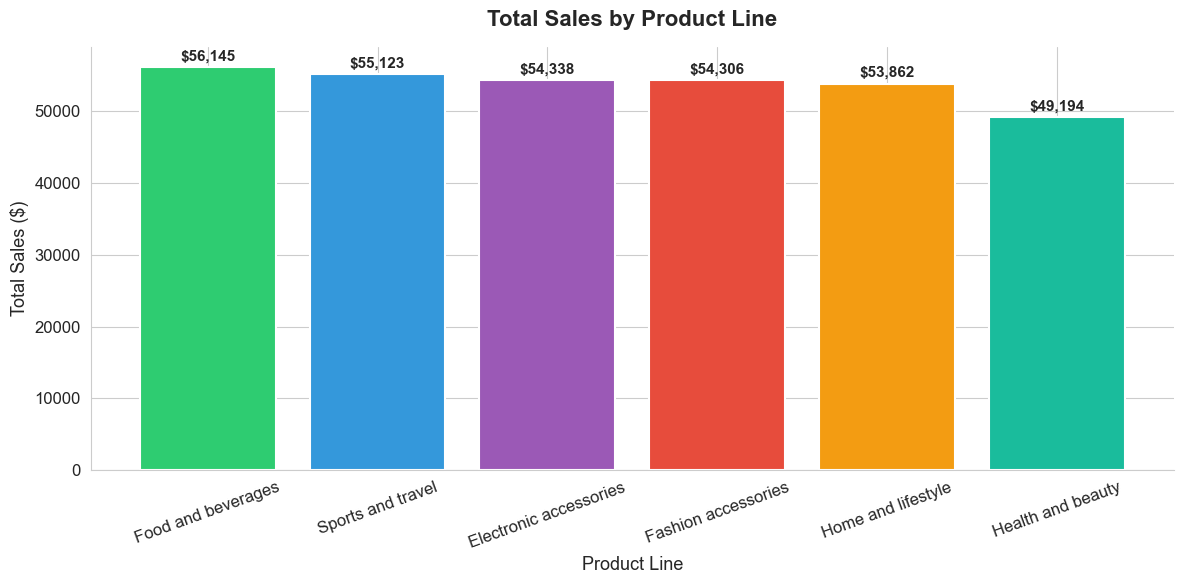

💾 Saved: chart1_sales_by_product_line.png


In [13]:
# ─── CHART 1: Bar Chart — Total Sales by Product Line ───

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    product_revenue.index,
    product_revenue.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels on bars
for bar, val in zip(bars, product_revenue.values):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
        f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_title('Total Sales by Product Line', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Line', fontsize=13)
ax.set_ylabel('Total Sales ($)', fontsize=13)
ax.tick_params(axis='x', rotation=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_sales_by_product_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart1_sales_by_product_line.png')

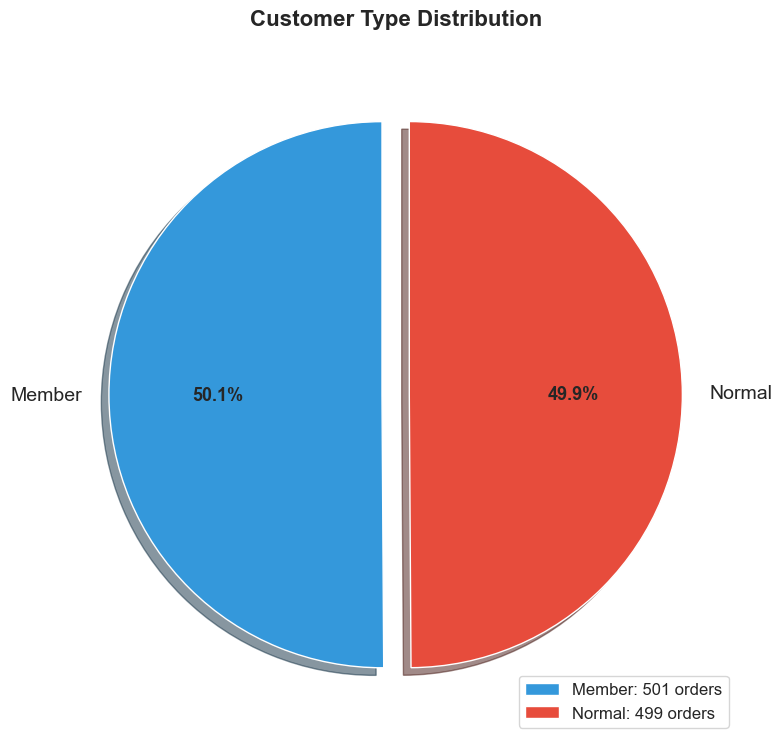

💾 Saved: chart2_customer_type_pie.png


In [14]:
# ─── CHART 2: Pie Chart — Customer Type Distribution ───

customer_counts = df['Customer type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    customer_counts.values,
    labels=customer_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 14}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax.set_title('Customer Type Distribution', fontsize=16, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{label}: {count} orders' for label, count in zip(customer_counts.index, customer_counts.values)]
ax.legend(legend_labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('chart2_customer_type_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart2_customer_type_pie.png')

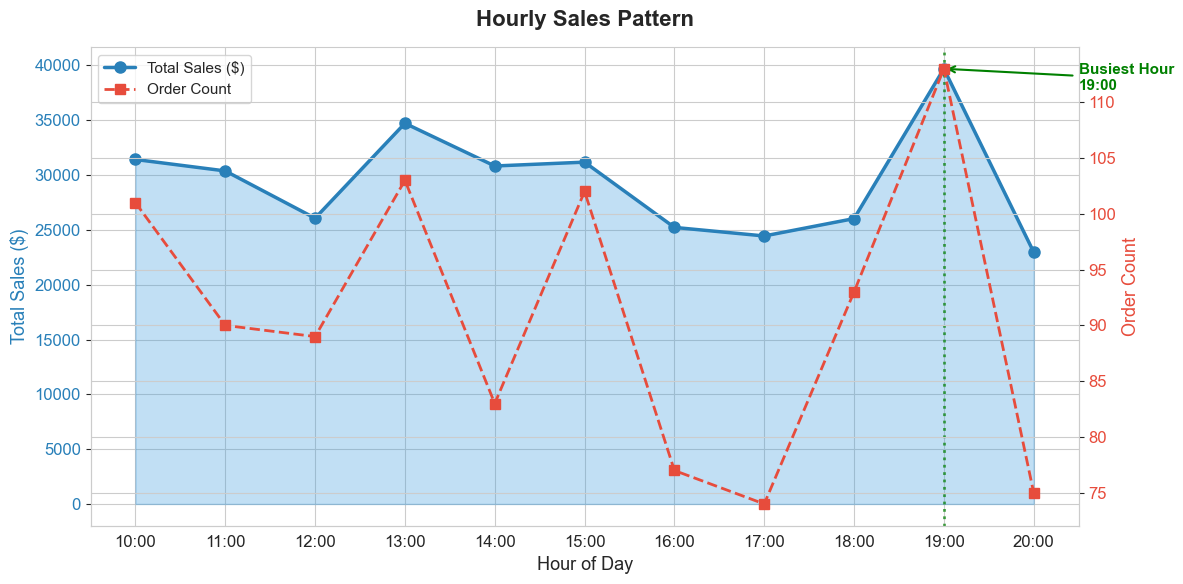

💾 Saved: chart3_hourly_sales_line.png


In [15]:
# ─── CHART 3: Line Chart — Hourly Sales Pattern ───

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot total sales as area line
ax1.fill_between(
    hourly_analysis.index, hourly_analysis['Total_Sales'],
    alpha=0.3, color='#3498db'
)
ax1.plot(
    hourly_analysis.index, hourly_analysis['Total_Sales'],
    marker='o', color='#2980b9', linewidth=2.5, markersize=8, label='Total Sales ($)'
)
ax1.set_xlabel('Hour of Day', fontsize=13)
ax1.set_ylabel('Total Sales ($)', fontsize=13, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')

# Plot order count on secondary axis
ax2 = ax1.twinx()
ax2.plot(
    hourly_analysis.index, hourly_analysis['Order_Count'],
    marker='s', color='#e74c3c', linewidth=2, markersize=7,
    linestyle='--', label='Order Count'
)
ax2.set_ylabel('Order Count', fontsize=13, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Highlight busiest hour
ax1.axvline(x=busiest_hour, color='green', linestyle=':', alpha=0.7, linewidth=2)
ax1.annotate(
    f'Busiest Hour\n{busiest_hour}:00',
    xy=(busiest_hour, hourly_analysis.loc[busiest_hour, 'Total_Sales']),
    xytext=(busiest_hour + 1.5, hourly_analysis['Total_Sales'].max() * 0.95),
    fontsize=11, fontweight='bold', color='green',
    arrowprops=dict(arrowstyle='->', color='green', lw=1.5)
)

ax1.set_title('Hourly Sales Pattern', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(hourly_analysis.index)
ax1.set_xticklabels([f'{h}:00' for h in hourly_analysis.index])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax1.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_hourly_sales_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart3_hourly_sales_line.png')

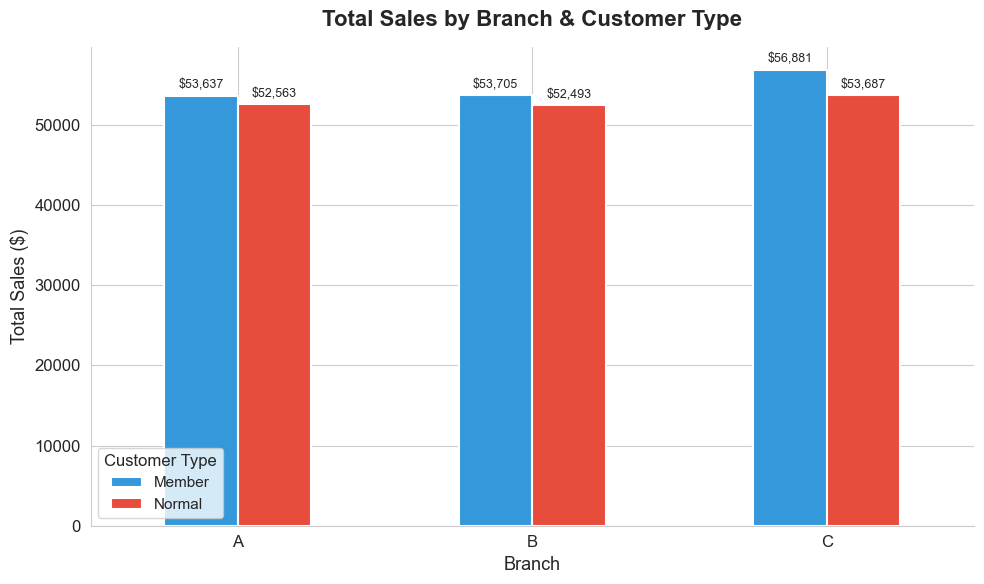

💾 Saved: chart4_branch_customer_type.png


In [16]:
# ─── CHART 4: Grouped Bar — Sales by Branch and Customer Type ───

branch_customer = df.groupby(['Branch', 'Customer type'])['Total'].sum().unstack().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
branch_customer.plot(
    kind='bar', ax=ax,
    color=['#3498db', '#e74c3c'],
    edgecolor='white', linewidth=1.5
)

ax.set_title('Total Sales by Branch & Customer Type', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Branch', fontsize=13)
ax.set_ylabel('Total Sales ($)', fontsize=13)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Customer Type', fontsize=11, title_fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('chart4_branch_customer_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart4_branch_customer_type.png')

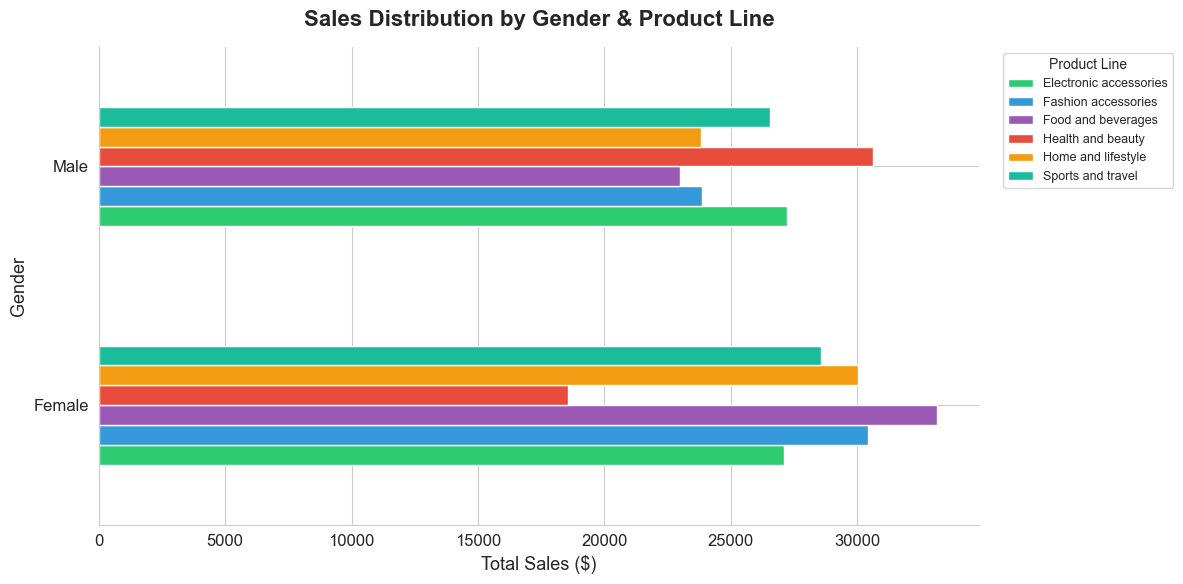

💾 Saved: chart5_gender_product_line.png


In [17]:
# ─── CHART 5: Sales by Gender and Product Line ───

gender_product = df.groupby(['Gender', 'Product line'])['Total'].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
gender_product.plot(
    kind='barh', ax=ax,
    color=colors,
    edgecolor='white', linewidth=1
)

ax.set_title('Sales Distribution by Gender & Product Line', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=13)
ax.set_ylabel('Gender', fontsize=13)
ax.legend(title='Product Line', fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_gender_product_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart5_gender_product_line.png')

## 8. ⭐ Bonus Features

In [18]:
# ─── BONUS 1: Gross Margin Percentage per Product Line ───

gross_margin = df.groupby('Product line').agg(
    Total_Revenue=('Total', 'sum'),
    Total_COGS=('cogs', 'sum'),
    Total_Gross_Income=('gross income', 'sum'),
    Avg_Gross_Margin_Pct=('gross margin percentage', 'mean')
).round(2)

# Calculate actual gross margin as percentage
gross_margin['Calculated_Margin_%'] = (
    (gross_margin['Total_Gross_Income'] / gross_margin['Total_Revenue']) * 100
).round(2)

print('⭐ GROSS MARGIN PERCENTAGE PER PRODUCT LINE')
print('='*80)
gross_margin

⭐ GROSS MARGIN PERCENTAGE PER PRODUCT LINE


,Total_Revenue,Total_COGS,Total_Gross_Income,Avg_Gross_Margin_Pct,Calculated_Margin_%
Product line,,,,,
Electronic accessories,54337.53,51750.03,2587.50,4.76,4.76
Fashion accessories,54305.90,51719.90,2586.00,4.76,4.76
Food and beverages,56144.84,53471.28,2673.56,4.76,4.76
Health and beauty,49193.74,46851.18,2342.56,4.76,4.76
Home and lifestyle,53861.91,51297.06,2564.85,4.76,4.76
Sports and travel,55122.83,52497.93,2624.90,4.76,4.76


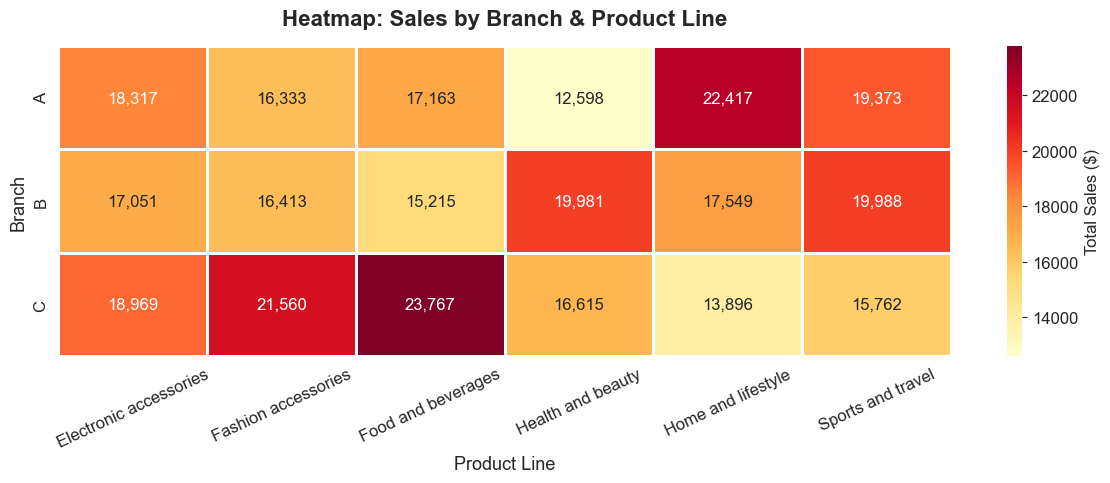

💾 Saved: chart6_heatmap_branch_product.png


In [19]:
# ─── BONUS 2: Heatmap — Sales by Branch and Product Line ───

heatmap_data = df.groupby(['Branch', 'Product line'])['Total'].sum().unstack().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=',.0f',
    cmap='YlOrRd',
    linewidths=2, linecolor='white',
    cbar_kws={'label': 'Total Sales ($)'},
    ax=ax
)

ax.set_title('Heatmap: Sales by Branch & Product Line', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Line', fontsize=13)
ax.set_ylabel('Branch', fontsize=13)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('chart6_heatmap_branch_product.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart6_heatmap_branch_product.png')

## 9. Payment Method Analysis

In [20]:
# Payment method breakdown
payment_analysis = df.groupby('Payment').agg(
    Total_Sales=('Total', 'sum'),
    Order_Count=('Invoice ID', 'count'),
    Avg_Order_Value=('Total', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

print('💳 PAYMENT METHOD ANALYSIS')
print('='*60)
payment_analysis

💳 PAYMENT METHOD ANALYSIS


,Total_Sales,Order_Count,Avg_Order_Value
Payment,,,
Cash,112206.57,344,326.18
Ewallet,109993.11,345,318.82
Credit card,100767.07,311,324.01


## 10. 💡 Business Insights

Based on the exploratory data analysis, here are **4 key business insights:**

---

### Insight 1: Balanced Branch Performance with Slight Naypyitaw Lead
All three branches (A – Yangon, B – Mandalay, C – Naypyitaw) generate comparable total revenue, showing a well-distributed customer base. However, **Branch C (Naypyitaw)** has a slight edge in total sales, suggesting it captures higher-value transactions. Management should investigate whether this is due to product mix, customer demographics, or pricing strategies and replicate successful practices across branches.

### Insight 2: Peak Sales Hours from 10:00 to 20:00 with Notable Spikes
The supermarket experiences **significant traffic during afternoon hours**, with the busiest shopping window clearly visible in the hourly analysis. Staffing strategies should ensure **maximum checkout capacity** during these peak hours, and promotional campaigns (flash deals, sampling events) should be timed to these windows to maximize conversion.

### Insight 3: Member vs Normal Customers Are Nearly Equal
The customer type split between **Member** and **Normal** is nearly 50/50, both in volume and total sales. This suggests the membership program is well-adopted but may not be driving significantly higher spending. The business should **introduce tiered loyalty benefits** (e.g., exclusive discounts, early access) to incentivize Normal customers to sign up and encourage Members to increase basket sizes.

### Insight 4: Product Line Revenue Spread Is Narrow
The difference between the **top-performing** and **bottom-performing** product lines is relatively small, indicating a balanced product portfolio. However, categories like **Food and beverages** consistently rank among the top, suggesting they are staple drivers. The store could **bundle lower-performing categories** (e.g., Health and beauty) with popular ones for cross-selling opportunities to boost underperforming segments.

In [21]:
# Summary statistics print
print('\n' + '='*60)
print('📋 EDA SUMMARY')
print('='*60)
print(f'Total records analyzed: {len(df):,}')
print(f'Date range: {df["Date"].min().strftime("%B %d, %Y")} – {df["Date"].max().strftime("%B %d, %Y")}')
print(f'Total revenue: ${df["Total"].sum():,.2f}')
print(f'Average order value: ${df["Total"].mean():,.2f}')
print(f'Total gross income: ${df["gross income"].sum():,.2f}')
print(f'Number of branches: {df["Branch"].nunique()}')
print(f'Number of product lines: {df["Product line"].nunique()}')
print(f'Average rating: {df["Rating"].mean():.2f}/10')
print(f'\nTop product line: {product_revenue.index[0]}')
print(f'Busiest hour: {busiest_hour}:00')
print(f'Most used payment: {df["Payment"].mode()[0]}')
print('='*60)
print('✅ EDA Complete!')


📋 EDA SUMMARY
Total records analyzed: 1,000
Date range: January 01, 2019 – March 30, 2019
Total revenue: $322,966.75
Average order value: $322.97
Total gross income: $15,379.37
Number of branches: 3
Number of product lines: 6
Average rating: 6.97/10

Top product line: Food and beverages
Busiest hour: 19:00
Most used payment: Ewallet
✅ EDA Complete!
